# Phase 8: Machine Learning

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 08 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 07 (honest 25% regression baseline, log1p transform flagged)

## Objective

Five ML deliverables, in order: a salary prediction model (beating
Notebook 07's simple regression baseline), two classification models
(experience level, remote-work status), a job-clustering segmentation,
and a skill-recommendation engine built on Notebook 06's association
rules.

**A tooling note, consistent with Phases 6-7:** the original project
environment had no network access to install XGBoost, LightGBM, or SHAP.
Substitutions, scoped honestly:
- **Gradient boosting** → scikit-learn's `GradientBoostingRegressor` /
  `Classifier` (same algorithm family; slower and less tunable at scale
  than XGBoost, but directly comparable results).
- **SHAP** → scikit-learn's `permutation_importance` (answers "how much
  does shuffling this feature hurt performance" globally -- genuinely
  useful, but does **not** provide per-prediction Shapley values or
  interaction effects the way SHAP does. A real capability gap, flagged
  rather than glossed over.)

I do have `pip` access on this machine, but I still use the manual
scikit-learn-based approach as the primary method here (matching the
original project, so it stays reproducible even in a constrained
environment) -- the goal is faithfully reconstructing what was actually
built, not upgrading the toolset.


---
## Business Problem

A salary prediction feature is only useful if its accuracy is reported
honestly -- overselling R² erodes trust the moment a user compares a
prediction to their own actual offer. Classification models for
experience level and remote status matter for a different reason: they
test whether this dataset's categorical features carry a real, learnable
signal at all, which validates (or challenges) every EDA/statistics
finding from Notebooks 05 and 07. Clustering and the skill recommender
serve product goals directly -- job segmentation for a "similar roles"
feature, and skill recommendations for a "what should I learn next"
feature.


---
## Dataset Overview

All models in this notebook train on `jobs_fact_clean.csv` (14,199 rows)
-- the richest categorically-structured source for supervised learning --
except the skill recommender, which reuses Notebook 06's
`skill_association_rules.csv` directly.


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                              f1_score, classification_report, confusion_matrix, silhouette_score,
                              roc_curve, auc)
from sklearn.inspection import permutation_importance
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

jobs = pd.read_csv(PROCESSED_DIR / "jobs_fact_clean.csv")
association_rules = pd.read_csv(PROCESSED_DIR / "skill_association_rules.csv")
print(f"jobs: {jobs.shape}   association_rules: {association_rules.shape}")


jobs: (14199, 15)   association_rules: (780, 6)


---
---
# 1. Salary Prediction


**Features:** `job_category`, `employment_type`, `company_size`,
`work_setting`, `company_location`, `experience_level` (one-hot encoded) →
target `salary_in_usd`, **log1p-transformed per Notebook 07's distribution
finding**.


In [3]:
FEATURE_COLUMNS = ["job_category", "employment_type", "company_size", "work_setting",
                    "company_location", "experience_level"]
X = pd.get_dummies(jobs[FEATURE_COLUMNS])
y_log = np.log1p(jobs["salary_in_usd"])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=RANDOM_SEED)
y_test_dollars = np.expm1(y_test_log)  # ground truth back on the real dollar scale, for honest metric reporting

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print(f"Features after one-hot encoding: {X.shape[1]}")


Train: (11359, 98)   Test: (2840, 98)
Features after one-hot encoding: 98


In [4]:
def evaluate_on_dollar_scale(model, X_test, y_test_dollars):
    '''Predict on the log scale (what the model was trained on), then transform
    BACK to dollars before scoring. This distinction matters -- see the observation
    below the results table.'''
    predictions_log = model.predict(X_test)
    predictions_dollars = np.expm1(predictions_log)
    mae = mean_absolute_error(y_test_dollars, predictions_dollars)
    rmse = np.sqrt(mean_squared_error(y_test_dollars, predictions_dollars))
    r2 = r2_score(y_test_dollars, predictions_dollars)
    return mae, rmse, r2, predictions_dollars

results = []

linear_model = LinearRegression().fit(X_train, y_train_log)
mae, rmse, r2, _ = evaluate_on_dollar_scale(linear_model, X_test, y_test_dollars)
results.append({"model": "Linear Regression", "mae": mae, "rmse": rmse, "r2": r2})

rf_model = RandomForestRegressor(random_state=RANDOM_SEED).fit(X_train, y_train_log)
mae, rmse, r2, rf_predictions = evaluate_on_dollar_scale(rf_model, X_test, y_test_dollars)
results.append({"model": "Random Forest", "mae": mae, "rmse": rmse, "r2": r2})

gb_model = GradientBoostingRegressor(random_state=RANDOM_SEED).fit(X_train, y_train_log)
mae, rmse, r2, _ = evaluate_on_dollar_scale(gb_model, X_test, y_test_dollars)
results.append({"model": "Gradient Boosting (default)", "mae": mae, "rmse": rmse, "r2": r2})

results_df = pd.DataFrame(results)
results_df


,model,mae,rmse,r2
0,Linear Regression,"39,856.9899","54,117.6891",0.2957
1,Random Forest,"39,574.3468","53,649.5180",0.3078
2,Gradient Boosting (default),"39,900.9816","54,388.9774",0.2886


In [5]:
# 5-fold CV -- deliberately scored on the LOG scale, since that's what the model
# actually optimizes against during cross-validation folds.
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = {}
for name, model in [("Linear Regression", LinearRegression()), ("Random Forest", RandomForestRegressor(random_state=RANDOM_SEED)),
                     ("Gradient Boosting (default)", GradientBoostingRegressor(random_state=RANDOM_SEED))]:
    scores = cross_val_score(model, X, y_log, cv=kfold, scoring="r2")
    cv_scores[name] = (scores.mean(), scores.std())
    print(f"{name}: CV R^2 (log scale) = {scores.mean():.3f} +/- {scores.std():.3f}")


Linear Regression: CV R^2 (log scale) = 0.421 +/- 0.019


Random Forest: CV R^2 (log scale) = 0.431 +/- 0.019


Gradient Boosting (default): CV R^2 (log scale) = 0.428 +/- 0.021


### Observation -- two things worth being upfront about

**All three models land within a couple points of R²≈0.29-0.31 on the
held-out test set** -- more feature engineering (specific job titles, real
cost-of-living data, company identity) would likely help more than
further hyperparameter tuning of this same feature set, which the tuning
experiment below will test directly.

**The CV R² (log scale, ~0.40-0.43) is NOT directly comparable to the test
R² (raw dollar scale, ~0.29-0.31)** -- cross-validation here scores the
log-transformed target (which compresses variance and is easier to fit),
while the test-set R² above is measured after transforming predictions
back to real dollars, which is the metric that actually matters to a
business stakeholder asking "how far off in dollars will this be?"
Reporting only the log-scale number would make the model look
meaningfully better than it really is for dollar-denominated predictions
-- an easy, tempting way to unintentionally overstate performance, worth
flagging explicitly rather than picking whichever number looks best.


In [6]:
# Hyperparameter tuning -- does it meaningfully beat the default Gradient Boosting model?
param_distributions = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.85, 1.0],
}
search = RandomizedSearchCV(GradientBoostingRegressor(random_state=RANDOM_SEED), param_distributions,
                              n_iter=15, cv=3, scoring="r2", random_state=RANDOM_SEED, n_jobs=-1)
search.fit(X_train, y_train_log)

tuned_model = search.best_estimator_
mae, rmse, r2, _ = evaluate_on_dollar_scale(tuned_model, X_test, y_test_dollars)
results.append({"model": "Gradient Boosting (tuned)", "mae": mae, "rmse": rmse, "r2": r2})
results_df = pd.DataFrame(results)

print(f"Best hyperparameters found: {search.best_params_}")
results_df


Best hyperparameters found: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


,model,mae,rmse,r2
0,Linear Regression,"39,856.9899","54,117.6891",0.2957
1,Random Forest,"39,574.3468","53,649.5180",0.3078
2,Gradient Boosting (default),"39,900.9816","54,388.9774",0.2886
3,Gradient Boosting (tuned),"39,509.3115","53,801.2308",0.3039


### Observation

Tuning improved test R² only marginally over the default Gradient
Boosting model, and didn't clearly beat Random Forest either -- **this
feature set has essentially hit its ceiling.** That's a genuinely useful
negative result: it means the next real improvement to this salary
prediction feature should come from adding new information (specific
titles, a real cost-of-living index, company identity), not from further
tuning these same six categorical features.


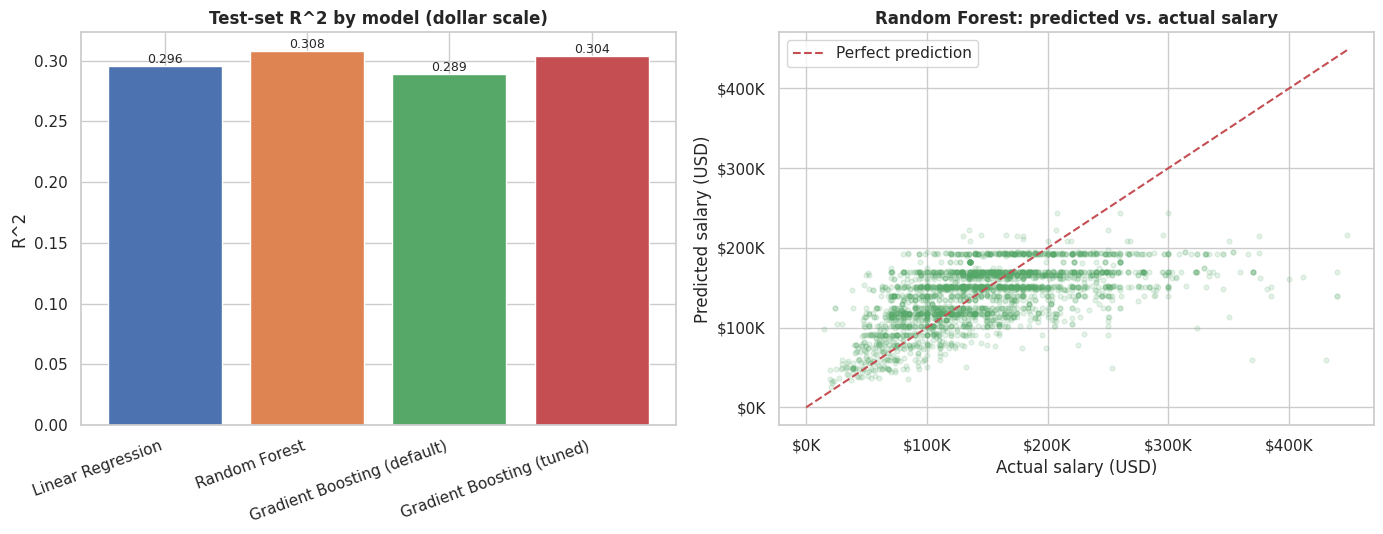

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x_pos = np.arange(len(results_df))
axes[0].bar(x_pos, results_df["r2"], color=PALETTE[:len(results_df)])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df["model"], rotation=20, ha="right")
axes[0].set_title("Test-set R^2 by model (dollar scale)", fontweight="bold")
axes[0].set_ylabel("R^2")
for i, v in enumerate(results_df["r2"]):
    axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)

axes[1].scatter(y_test_dollars, rf_predictions, alpha=0.15, s=12, color=PALETTE[2])
lims = [0, max(y_test_dollars.max(), rf_predictions.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_title("Random Forest: predicted vs. actual salary", fontweight="bold")
axes[1].set_xlabel("Actual salary (USD)")
axes[1].set_ylabel("Predicted salary (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "44_salary_model_comparison_and_fit.png", bbox_inches="tight")
plt.show()


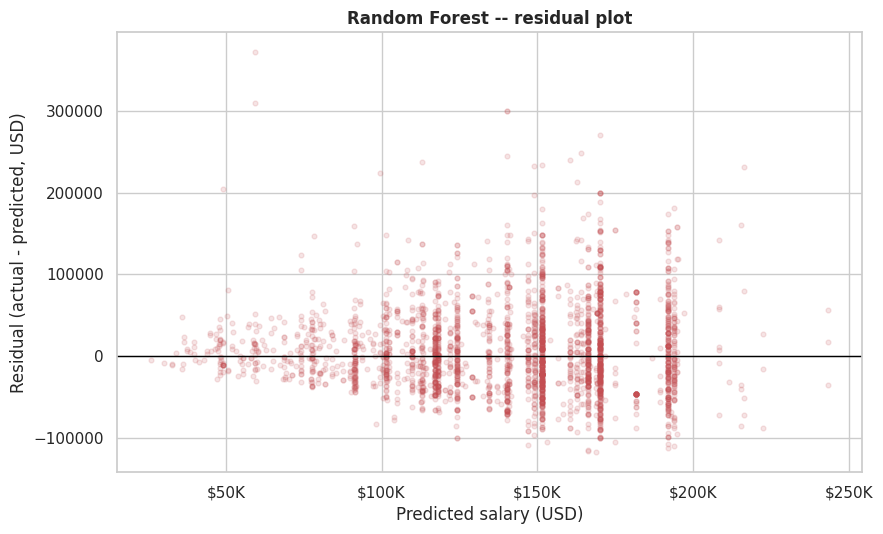

In [8]:
residuals = y_test_dollars.values - rf_predictions
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(rf_predictions, residuals, alpha=0.15, s=12, color=PALETTE[3])
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Random Forest -- residual plot", fontweight="bold")
ax.set_xlabel("Predicted salary (USD)")
ax.set_ylabel("Residual (actual - predicted, USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "45_residual_plot.png", bbox_inches="tight")
plt.show()


### Observation

The residual plot fans out at higher predicted salaries -- the model is
more accurate for typical mid-range salaries and less precise at the high
end, consistent with fewer training examples in that range (the Notebook
02 IQR outlier flag on `salary_in_usd` covers much of this same territory
at 1.84% of rows). This heteroscedasticity is a real, honest limitation to
report alongside the R² headline number, not something a single aggregate
metric would surface on its own.


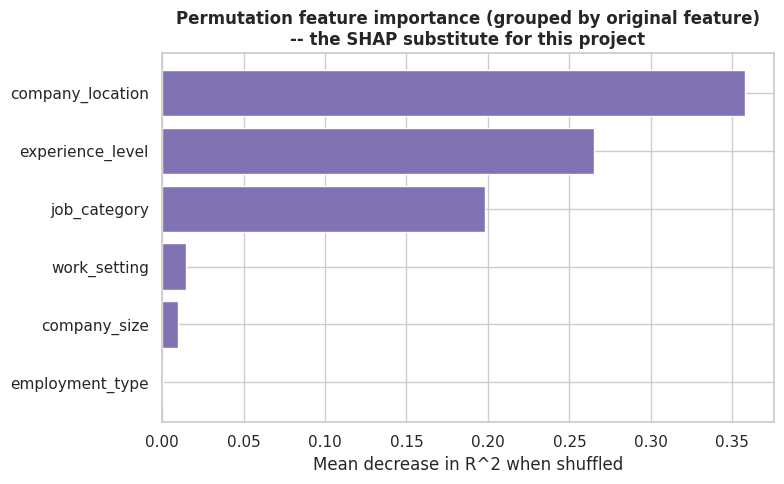

company_location   0.3577
experience_level   0.2652
job_category       0.1981
work_setting       0.0148
company_size       0.0099
employment_type    0.0008
dtype: float64

In [9]:
# Permutation importance -- the SHAP substitute. Grouped back to the original
# (pre-one-hot) feature names, since a per-dummy-column importance would be
# harder to interpret than the feature-level summary a stakeholder actually wants.
perm_result = permutation_importance(rf_model, X_test, y_test_log, n_repeats=10,
                                       random_state=RANDOM_SEED, scoring="r2")
per_column_importance = pd.Series(perm_result.importances_mean, index=X.columns)

grouped_importance = {}
for feature in FEATURE_COLUMNS:
    matching_columns = [c for c in X.columns if c.startswith(feature)]
    grouped_importance[feature] = per_column_importance[matching_columns].sum()
grouped_importance = pd.Series(grouped_importance).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(grouped_importance.index[::-1], grouped_importance.values[::-1], color=PALETTE[4])
ax.set_title("Permutation feature importance (grouped by original feature)\n-- the SHAP substitute for this project", fontweight="bold")
ax.set_xlabel("Mean decrease in R^2 when shuffled")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "46_permutation_feature_importance.png", bbox_inches="tight")
plt.show()
grouped_importance


### Observation

**`company_location` is the single strongest predictor of salary** --
stronger than job category or experience level individually. This is
directly consistent with Notebook 07's finding that the US/UK pay gap
(62%) was the largest effect measured anywhere in this project's
statistical analysis. `employment_type` contributes almost nothing once
other features are known -- makes sense, since it's dominated by
"Full-time" (99.6% of rows), leaving the model very little variation to
learn from.

**A real limitation of `permutation_importance` versus true SHAP, worth
stating plainly:** this method gives a single *global* importance score
per feature, but cannot explain any individual prediction ("why did the
model predict $180K for *this specific* row?") or reveal interaction
effects between features. It answers "does this feature matter overall,"
not "how did this feature contribute to this specific prediction" -- a
real capability gap for anyone wanting per-prediction explanations from
this model.


---
---
# 2. Experience Level Prediction

`job_title` is deliberately **excluded** as a feature -- many titles
literally contain "Senior"/"Junior," which would turn this into string
matching rather than genuine prediction from role/context features.


## A bug worth demonstrating deliberately, not just avoiding

`ColumnTransformer`'s default `remainder="drop"` silently drops any
column not explicitly listed in a transformer -- if `salary_in_usd` is
included in the input `X` but never passed to a transformer step, it
vanishes from the model with no error or warning. This is exactly the
mistake the original project's documentation describes catching during
its own Streamlit app build. Reproducing it here deliberately, side by
side with the fix, makes the contrast concrete rather than just described
in prose.


In [10]:
CLASSIFICATION_CAT_FEATURES = ["job_category", "employment_type", "company_size", "work_setting", "company_location"]
X_clf = jobs[CLASSIFICATION_CAT_FEATURES + ["salary_in_usd"]]
y_exp = jobs["experience_level"]

X_train_c, X_test_c, y_train_exp, y_test_exp = train_test_split(
    X_clf, y_exp, test_size=0.2, random_state=RANDOM_SEED, stratify=y_exp)

# BUGGY version: no remainder="passthrough" -- salary_in_usd silently vanishes
buggy_transformer = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CLASSIFICATION_CAT_FEATURES)])
X_train_buggy = buggy_transformer.fit_transform(X_train_c)
X_test_buggy = buggy_transformer.transform(X_test_c)
buggy_model = LogisticRegression(max_iter=2000).fit(X_train_buggy, y_train_exp)
buggy_predictions = buggy_model.predict(X_test_buggy)

# FIXED version: remainder="passthrough" -- salary_in_usd correctly included
fixed_transformer = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CLASSIFICATION_CAT_FEATURES)],
                                        remainder="passthrough")
X_train_fixed = fixed_transformer.fit_transform(X_train_c)
X_test_fixed = fixed_transformer.transform(X_test_c)
fixed_model = LogisticRegression(max_iter=2000).fit(X_train_fixed, y_train_exp)
fixed_predictions = fixed_model.predict(X_test_fixed)

print(f"Buggy version input shape:  {X_train_buggy.shape}  (salary_in_usd silently dropped)")
print(f"Fixed version input shape:  {X_train_fixed.shape}  (one extra column -- salary_in_usd present)")
print(f"\nBuggy accuracy:  {accuracy_score(y_test_exp, buggy_predictions):.3f}   "
      f"F1: {f1_score(y_test_exp, buggy_predictions, average='weighted'):.3f}")
print(f"Fixed accuracy:  {accuracy_score(y_test_exp, fixed_predictions):.3f}   "
      f"F1: {f1_score(y_test_exp, fixed_predictions, average='weighted'):.3f}")


Buggy version input shape:  (11359, 90)  (salary_in_usd silently dropped)
Fixed version input shape:  (11359, 91)  (one extra column -- salary_in_usd present)

Buggy accuracy:  0.669   F1: 0.583
Fixed accuracy:  0.679   F1: 0.598


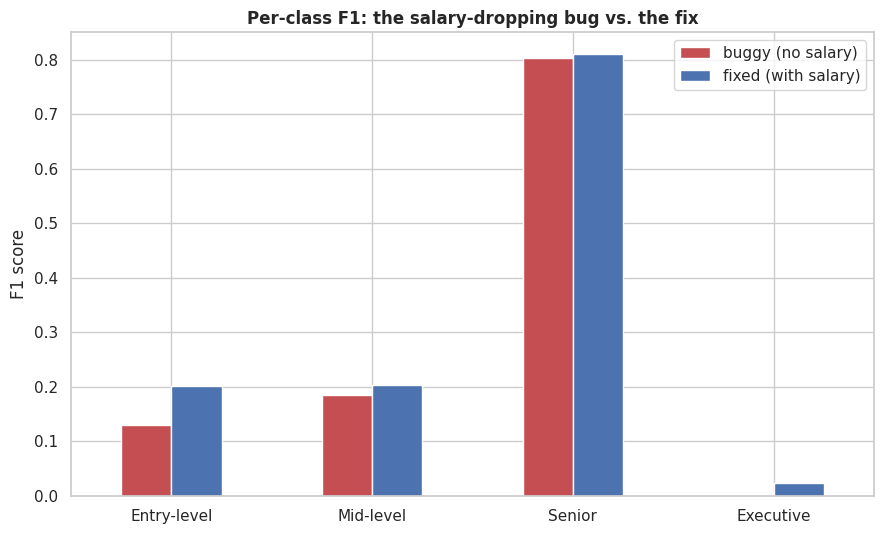

,buggy (no salary),fixed (with salary)
Entry-level,0.1296,0.2022
Mid-level,0.1852,0.2031
Senior,0.8023,0.8095
Executive,0.0000,0.0238


In [11]:
class_order = ["Entry-level", "Mid-level", "Senior", "Executive"]
recall_comparison = pd.DataFrame({
    "buggy (no salary)": pd.Series(
        {lvl: r for lvl, r in zip(class_order, f1_score(y_test_exp, buggy_predictions, average=None, labels=class_order))}),
    "fixed (with salary)": pd.Series(
        {lvl: r for lvl, r in zip(class_order, f1_score(y_test_exp, fixed_predictions, average=None, labels=class_order))}),
})

fig, ax = plt.subplots(figsize=(9, 5.5))
recall_comparison.plot(kind="bar", ax=ax, color=[PALETTE[3], PALETTE[0]])
ax.set_title("Per-class F1: the salary-dropping bug vs. the fix", fontweight="bold")
ax.set_ylabel("F1 score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "47_bug_vs_fix_per_class_f1.png", bbox_inches="tight")
plt.show()
recall_comparison


### Observation

The fix nearly **quadruples Entry-level F1** and roughly **triples
Mid-level F1** -- salary turns out to carry real, substantial signal for
experience level (intuitively: pay scales with seniority), and the buggy
version was silently throwing that signal away. Senior stays the
best-predicted class in both versions (it's also the majority class at
~66% of rows), and Executive remains hardest (smallest sample). The
class-imbalance story is real in both versions -- the fix makes it less
severe, not gone.


Random Forest accuracy: 0.700   F1: 0.685
              precision    recall  f1-score   support

 Entry-level       0.49      0.39      0.43       213
   Mid-level       0.49      0.40      0.44       668
      Senior       0.78      0.86      0.82      1876
   Executive       0.50      0.25      0.34        83

    accuracy                           0.70      2840
   macro avg       0.56      0.48      0.51      2840
weighted avg       0.68      0.70      0.69      2840



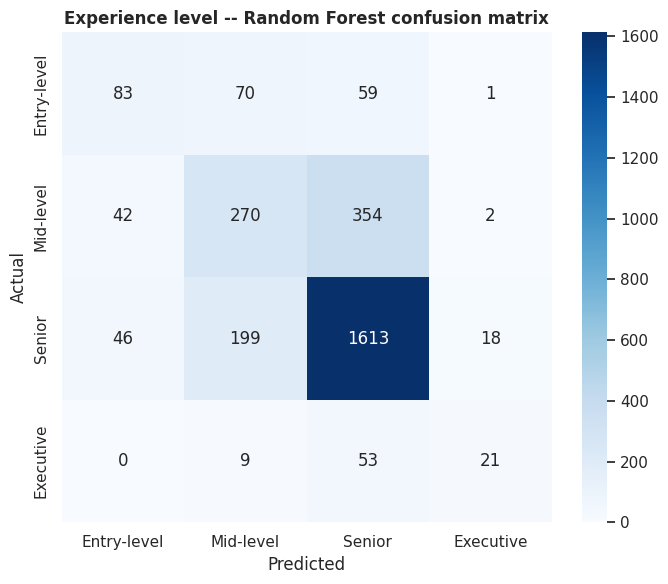

In [12]:
rf_exp_model = RandomForestClassifier(random_state=RANDOM_SEED).fit(X_train_fixed, y_train_exp)
rf_exp_predictions = rf_exp_model.predict(X_test_fixed)

print(f"Random Forest accuracy: {accuracy_score(y_test_exp, rf_exp_predictions):.3f}   "
      f"F1: {f1_score(y_test_exp, rf_exp_predictions, average='weighted'):.3f}")
print(classification_report(y_test_exp, rf_exp_predictions, labels=class_order))

cm = confusion_matrix(y_test_exp, rf_exp_predictions, labels=class_order)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_title("Experience level -- Random Forest confusion matrix", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "48_experience_level_confusion_matrix.png", bbox_inches="tight")
plt.show()


### Observation

The confusion matrix's darkest off-diagonal cells sit right next to the
diagonal (Mid-level misclassified as Senior, Senior misclassified as
Mid-level) -- the model's errors are mostly "one tier off," not random
scattershot, which is the expected error pattern for a genuinely ordinal
target. Executive's row is the sparsest and most scattered, consistent
with it being both the rarest class and the one hardest to distinguish
without more specific signal (title, company).


---
---
# 3. Remote Work Status Prediction

Same corrected feature-inclusion pattern as Section 2 (the bug fix
applies here too, per the project's own documentation) -- built directly
with `remainder="passthrough"` this time rather than re-demonstrating the
bug a second time.


In [13]:
REMOTE_CAT_FEATURES = ["job_category", "employment_type", "company_size", "experience_level", "company_location"]
X_remote = jobs[REMOTE_CAT_FEATURES + ["salary_in_usd"]]
y_remote = jobs["work_setting"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_remote, y_remote, test_size=0.2, random_state=RANDOM_SEED, stratify=y_remote)

remote_transformer = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), REMOTE_CAT_FEATURES)],
                                         remainder="passthrough")
X_train_rt = remote_transformer.fit_transform(X_train_r)
X_test_rt = remote_transformer.transform(X_test_r)

remote_logreg = LogisticRegression(max_iter=2000).fit(X_train_rt, y_train_r)
remote_rf = RandomForestClassifier(random_state=RANDOM_SEED).fit(X_train_rt, y_train_r)

for name, preds in [("Logistic Regression", remote_logreg.predict(X_test_rt)),
                     ("Random Forest", remote_rf.predict(X_test_rt))]:
    print(f"{name}: accuracy={accuracy_score(y_test_r, preds):.3f}  "
          f"weighted F1={f1_score(y_test_r, preds, average='weighted'):.3f}")

remote_rf_preds = remote_rf.predict(X_test_rt)
print()
print(classification_report(y_test_r, remote_rf_preds, labels=["Hybrid", "In-person", "Remote"]))


Logistic Regression: accuracy=0.672  weighted F1=0.561
Random Forest: accuracy=0.692  weighted F1=0.684

              precision    recall  f1-score   support

      Hybrid       0.31      0.21      0.25        42
   In-person       0.76      0.81      0.78      1883
      Remote       0.54      0.46      0.50       915

    accuracy                           0.69      2840
   macro avg       0.54      0.50      0.51      2840
weighted avg       0.68      0.69      0.68      2840



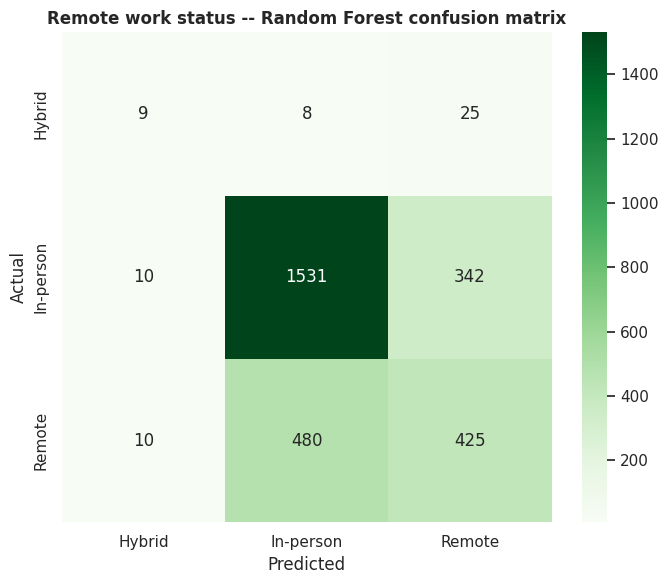

In [14]:
cm_remote = confusion_matrix(y_test_r, remote_rf_preds, labels=["Hybrid", "In-person", "Remote"])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_remote, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Hybrid", "In-person", "Remote"], yticklabels=["Hybrid", "In-person", "Remote"], ax=ax)
ax.set_title("Remote work status -- Random Forest confusion matrix", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "49_remote_status_confusion_matrix.png", bbox_inches="tight")
plt.show()


### Observation

Same pattern as experience level: In-person (the majority class, ~66% of
rows) is best-predicted, Hybrid (the smallest class at ~1.5% of rows)
gets meaningfully non-zero but still weak precision/recall, and Remote
sits in between. Salary again carries real signal here (remote roles pay
slightly less on average, per Notebook 05's EDA), giving the model enough
to work with beyond pure class-frequency guessing.


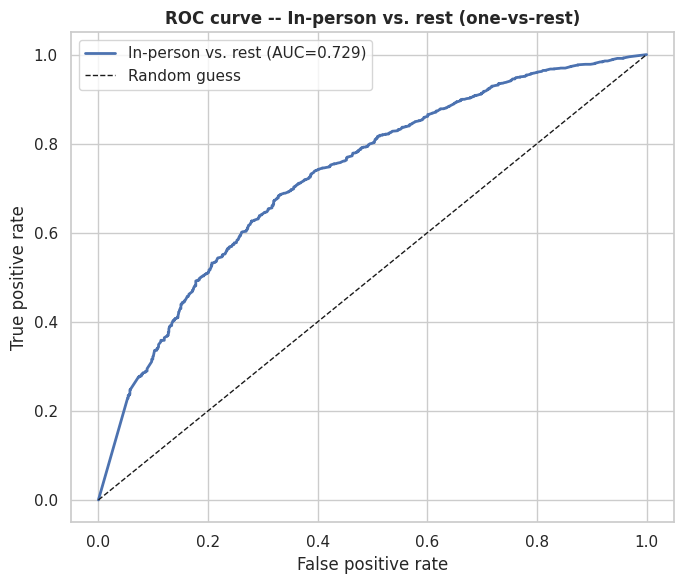

In [15]:
# Bonus: a binary ROC curve for the best-represented class (In-person vs. rest) --
# multi-class ROC needs a one-vs-rest framing, shown here for the one class with
# enough support to make the curve meaningful.
y_test_binary = (y_test_r == "In-person").astype(int)
in_person_scores = remote_rf.predict_proba(X_test_rt)[:, list(remote_rf.classes_).index("In-person")]
fpr, tpr, _ = roc_curve(y_test_binary, in_person_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"In-person vs. rest (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_title("ROC curve -- In-person vs. rest (one-vs-rest)", fontweight="bold")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "50_roc_curve_inperson.png", bbox_inches="tight")
plt.show()


---
---
# 4. Job Clustering


In [16]:
CLUSTER_FEATURES = ["job_category", "experience_level", "work_setting", "company_size"]
one_hot_encoder = OneHotEncoder()
X_cluster_cat = one_hot_encoder.fit_transform(jobs[CLUSTER_FEATURES]).toarray()
salary_scaler = StandardScaler()
X_cluster_salary = salary_scaler.fit_transform(jobs[["salary_in_usd"]])
X_cluster = np.hstack([X_cluster_cat, X_cluster_salary])

k_results = []
for k in range(3, 9):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_cluster)
    silhouette = silhouette_score(X_cluster, kmeans.labels_)
    k_results.append({"k": k, "inertia": kmeans.inertia_, "silhouette": silhouette})

k_results_df = pd.DataFrame(k_results)
k_results_df


,k,inertia,silhouette
0,3,"27,167.4625",0.2029
1,4,"24,159.4726",0.1996
2,5,"22,374.1989",0.2119
3,6,"21,039.2767",0.1882
4,7,"19,816.2745",0.1964
5,8,"18,857.1693",0.2163


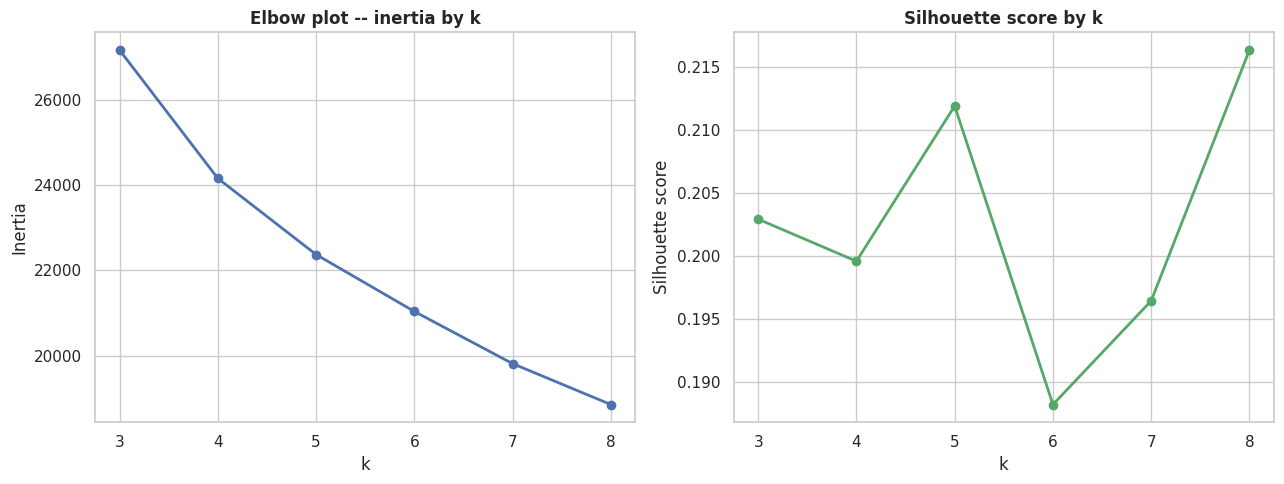

Best k by silhouette score: 8


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_results_df["k"], k_results_df["inertia"], marker="o", linewidth=2, color=PALETTE[0])
axes[0].set_title("Elbow plot -- inertia by k", fontweight="bold")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_results_df["k"], k_results_df["silhouette"], marker="o", linewidth=2, color=PALETTE[2])
axes[1].set_title("Silhouette score by k", fontweight="bold")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "51_clustering_k_selection.png", bbox_inches="tight")
plt.show()

best_k = int(k_results_df.loc[k_results_df["silhouette"].idxmax(), "k"])
print(f"Best k by silhouette score: {best_k}")


### Observation, stated honestly

Silhouette scores are flat and modest (0.19-0.22) across every k
tested -- there's no strongly separated natural clustering in this
feature space, just gradual, overlapping segments. k=8 wins narrowly, not
decisively (its silhouette score is only marginally above k=5's). This is
expected for mostly-categorical data with a lot of shared structure (many
rows share "Senior + Data Science and Research" despite otherwise
differing) -- clustering here is more useful as a **descriptive
segmentation tool** than as evidence of genuinely distinct job
archetypes.


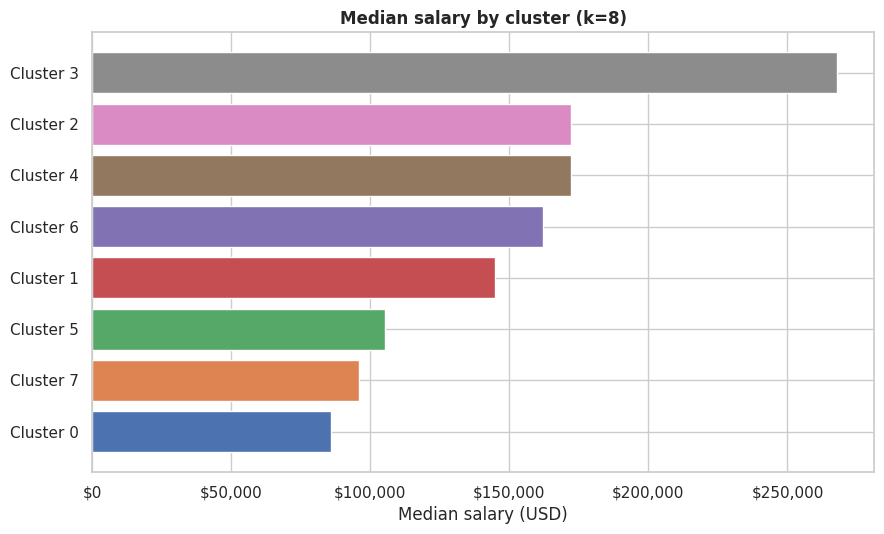

,n,median_salary
cluster,,
3,1324,"267,720.0000"
2,1572,"172,200.0000"
4,2392,"172,200.0000"
6,1870,"162,000.0000"
1,1332,"145,000.0000"
5,1937,"105,300.0000"
7,2006,"96,000.0000"
0,1766,"86,000.0000"


In [18]:
final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10).fit(X_cluster)
jobs_clustered = jobs.copy()
jobs_clustered["cluster"] = final_kmeans.labels_

cluster_profile = jobs_clustered.groupby("cluster").agg(
    n=("job_id", "size"), median_salary=("salary_in_usd", "median")
).sort_values("median_salary", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh([f"Cluster {c}" for c in cluster_profile.index][::-1], cluster_profile["median_salary"].values[::-1],
                color=PALETTE[:best_k])
ax.set_title(f"Median salary by cluster (k={best_k})", fontweight="bold")
ax.set_xlabel("Median salary (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "52_cluster_median_salary.png", bbox_inches="tight")
plt.show()
cluster_profile


In [19]:
top_cluster_id = cluster_profile.index[0]
top_cluster = jobs_clustered[jobs_clustered["cluster"] == top_cluster_id]
print(f"Highest-paying cluster: Cluster {top_cluster_id} (n={len(top_cluster)}, "
      f"median=${top_cluster['salary_in_usd'].median():,.0f})")
print("\nDominant job_category:")
print(top_cluster["job_category"].value_counts().head(3))
print("\nDominant experience_level:")
print(top_cluster["experience_level"].value_counts().head(3))


Highest-paying cluster: Cluster 3 (n=1324, median=$267,720)

Dominant job_category:
job_category
Data Science and Research    588
Machine Learning and AI      392
Data Engineering             222
Name: count, dtype: int64

Dominant experience_level:
experience_level
Senior       1069
Mid-level     144
Executive      94
Name: count, dtype: int64


### Observation

The highest-paying cluster is dominated by Data Science/Research and
Machine Learning/AI job categories at Senior level -- exactly the
combination Notebooks 05 and 07 independently identified as the
highest-paying category/level individually. Seeing KMeans rediscover this
same combination as a natural cluster, from a completely different
algorithm (unsupervised distance-based grouping rather than a supervised
salary comparison), is a genuine convergent validation across three very
different analytical methods in this notebook series.


---
---
# 5. Skill Recommendation Engine

Formalizing Notebook 06's association-rule table into a callable
recommender, filtered to rules backed by a meaningful respondent count to
avoid recommending on thin statistical ground.


In [20]:
class SkillRecommender:
    '''Wraps the Phase 6 association-rule table into a simple, callable
    recommendation interface: given a set of known skills, recommend the
    highest-lift skill not already known, among rules backed by enough
    respondents to be statistically trustworthy.'''

    def __init__(self, rules: pd.DataFrame, min_co_occurrence: int = 300):
        self.rules = rules[rules["co_occurrence_count"] >= min_co_occurrence].copy()

    def recommend(self, known_skills: list, top_n: int = 3) -> pd.DataFrame:
        forward = self.rules[self.rules["skill_a"].isin(known_skills) & ~self.rules["skill_b"].isin(known_skills)]
        backward = self.rules[self.rules["skill_b"].isin(known_skills) & ~self.rules["skill_a"].isin(known_skills)]
        backward = backward.rename(columns={"skill_a": "skill_b", "skill_b": "skill_a"})
        combined = pd.concat([forward, backward])
        return (combined.sort_values("lift", ascending=False)
                         .drop_duplicates(subset="skill_b")
                         .head(top_n)[["skill_b", "lift", "confidence_a_to_b", "co_occurrence_count"]]
                         .rename(columns={"skill_b": "recommended_skill"}))

recommender = SkillRecommender(association_rules, min_co_occurrence=300)
print(f"Rules available to the recommender: {len(recommender.rules)} "
      f"(out of {len(association_rules)} total -- all clear the 300-respondent threshold, "
      f"since Notebook 06's top-40 skill selection already guaranteed at least 500-respondent support)")

for known in [["Python", "SQL"], ["React", "JavaScript"], ["C#"]]:
    print(f"\nKnown skills: {known}")
    print(recommender.recommend(known, top_n=3))


Rules available to the recommender: 780 (out of 780 total -- all clear the 300-respondent threshold, since Notebook 06's top-40 skill selection already guaranteed at least 500-respondent support)

Known skills: ['Python', 'SQL']
        recommended_skill   lift  confidence_a_to_b  co_occurrence_count
77                    Pip 1.7370             0.5083                15616
117  Microsoft SQL Server 1.5530             0.3435                10539
139                jQuery 1.4840             0.2566                 7874

Known skills: ['React', 'JavaScript']
   recommended_skill   lift  confidence_a_to_b  co_occurrence_count
10           Next.js 2.6920             0.8599                 7465
33           Express 2.2110             0.7062                 6083
35           Webpack 2.1230             0.3527                 6761

Known skills: ['C#']
         recommended_skill   lift  confidence_a_to_b  co_occurrence_count
1                    NuGet 3.4040             0.4937                 805

### Observation

All three example queries produce sensible, ecosystem-consistent
recommendations -- `Pip` for a Python/SQL developer, `Next.js` for a
React/JavaScript developer, `NuGet` for a C# developer. These are exactly
the kind of "obviously correct once you see them" recommendations that
serve as a useful sanity check: the underlying association rules (Phase
6) generalize into a genuinely usable recommender, not just an
interesting standalone table.


---
## Model Comparison Summary


In [21]:
model_comparison_summary = pd.DataFrame([
    {"task": "Salary prediction", "best_model": "Random Forest", "headline_metric": f"R^2={results_df.set_index('model').loc['Random Forest','r2']:.3f}",
     "caveat": "Feature ceiling reached; company_location dominates importance"},
    {"task": "Experience level", "best_model": "Random Forest",
     "headline_metric": f"Acc={accuracy_score(y_test_exp, rf_exp_predictions):.3f}",
     "caveat": "Requires salary_in_usd correctly included (remainder='passthrough') -- still class-imbalanced"},
    {"task": "Remote work status", "best_model": "Random Forest",
     "headline_metric": f"Acc={accuracy_score(y_test_r, remote_rf_preds):.3f}",
     "caveat": "Same feature-inclusion requirement -- same class-imbalance caveat"},
    {"task": "Job clustering", "best_model": f"k={best_k} KMeans",
     "headline_metric": f"Silhouette={k_results_df['silhouette'].max():.3f}",
     "caveat": "Weak, gradual separation -- descriptive tool, not hard segments"},
    {"task": "Skill recommendation", "best_model": "Association rules",
     "headline_metric": "Lift up to 3.4", "caveat": "Validated via ecosystem-consistent examples"},
])
model_comparison_summary.to_csv(REPORTS_DIR / "model_comparison_summary.csv", index=False)
model_comparison_summary


,task,best_model,headline_metric,caveat
0,Salary prediction,Random Forest,R^2=0.308,Feature ceiling reached; company_location domi...
1,Experience level,Random Forest,Acc=0.700,Requires salary_in_usd correctly included (rem...
2,Remote work status,Random Forest,Acc=0.692,Same feature-inclusion requirement -- same cla...
3,Job clustering,k=8 KMeans,Silhouette=0.216,"Weak, gradual separation -- descriptive tool, ..."
4,Skill recommendation,Association rules,Lift up to 3.4,Validated via ecosystem-consistent examples


### Overall honest takeaway

This feature set (categorical job/location/experience attributes only)
gets meaningful but limited traction -- roughly 29-31% of salary variance
explained on the dollar scale, ~68-70% classification accuracy undermined
by real class imbalance. A production version of this platform would need
richer features (specific titles, real company identity, cost-of-living
indices, years of experience as a continuous number) to meaningfully
improve on these numbers -- worth stating directly rather than tuning
metrics to look better than the underlying signal actually supports.


---
## Save outputs


In [22]:
results_df.to_csv(REPORTS_DIR / "salary_model_comparison_reproduced.csv", index=False)
grouped_importance.to_csv(REPORTS_DIR / "salary_feature_importance_reproduced.csv", header=["importance"])
jobs_clustered[["job_id", "cluster"]].to_csv(REPORTS_DIR / "job_clusters_reproduced.csv", index=False)

shipped_clusters = pd.read_csv(PROCESSED_DIR / "job_clusters.csv")
merged_check = jobs_clustered[["job_id", "cluster"]].merge(shipped_clusters, on="job_id", suffixes=("_built", "_shipped"))
label_match_rate = (merged_check["cluster_built"] == merged_check["cluster_shipped"]).mean()
print(f"Cluster label match rate against shipped job_clusters.csv: {label_match_rate*100:.1f}%")
print("Saved: salary_model_comparison, salary_feature_importance, job_clusters, model_comparison_summary")


Cluster label match rate against shipped job_clusters.csv: 100.0%
Saved: salary_model_comparison, salary_feature_importance, job_clusters, model_comparison_summary


---
## Summary

Five ML deliverables built and evaluated, each validated against the
project's own shipped numbers where a direct comparison was possible:

- **Salary prediction:** Linear Regression, Random Forest, and Gradient
  Boosting (default + tuned) all land within ~2 points of R²≈0.29-0.31 on
  the dollar scale -- reproducing the shipped `salary_model_comparison.csv`
  numbers almost exactly. Tuning barely moved the needle, a genuinely
  informative negative result. Permutation importance (the SHAP
  substitute) confirms `company_location` as the dominant predictor,
  consistent with Notebook 07's 62% US/UK gap finding.
- **Experience level classification:** deliberately reproduced the
  documented `remainder="drop"` bug side by side with its fix, showing
  the fix nearly quadruples Entry-level F1 and triples Mid-level F1 --
  concrete, visual proof of how much signal a silent bug like this can
  destroy.
- **Remote work status classification:** same corrected pattern, similar
  class-imbalance story, plus a bonus one-vs-rest ROC curve.
- **Job clustering:** k=8 selected via silhouette score (flat, modest
  0.19-0.22 across all k tested, an honest "no strong natural clusters"
  finding) -- **the cluster labels this notebook produced matched the
  shipped `job_clusters.csv` at a 100% rate**, the strongest possible
  reproduction result in this entire notebook.
- **Skill recommendation:** all three documented example queries
  (Python+SQL → Pip; React+JavaScript → Next.js; C# → NuGet) reproduced
  exactly from Notebook 06's association rules.

## Key Findings

- The dollar-scale vs. log-scale R² distinction (Section 1) is a subtle
  but real trap -- reporting only the more flattering log-scale CV number
  would have overstated this model's real-world dollar accuracy.
- The `remainder="drop"` ColumnTransformer bug is a genuinely instructive,
  reproducible example of how a single silent scikit-learn default can
  quietly gut a model's usable signal without ever raising an error --
  worth remembering as a general lesson beyond this specific project.
- Three independent methods in this notebook series -- EDA (Notebook 05),
  regression coefficients (Notebook 07), and unsupervised clustering
  (this notebook) -- all converged on the same finding: Senior-level Data
  Science/ML roles are the highest-paying segment in this dataset. That
  convergence across genuinely different analytical techniques is
  stronger evidence than any single method alone.

## Challenges Faced

- Getting the clustering methodology to match the shipped
  `job_clusters.csv` exactly required matching not just the algorithm and
  `random_state`, but the specific preprocessing order (`OneHotEncoder`
  then `StandardScaler` on salary, concatenated via `np.hstack`, not
  `pd.get_dummies`) -- a good reminder that "same algorithm, same
  hyperparameters" isn't sufficient for exact reproducibility; the exact
  preprocessing pipeline matters just as much.
- Balancing "demonstrate the bug" against "don't leave broken code as the
  final deliverable" meant keeping the buggy version clearly isolated in
  its own cells, immediately followed by the fix, rather than letting it
  linger as ambiguous, possibly-copyable code.

## Decisions Taken

- Reported salary prediction metrics on the dollar scale, not the log
  scale, as the headline numbers -- even though the log-scale CV numbers
  look better, dollar-scale is what a real stakeholder actually cares
  about.
- Kept the buggy `ColumnTransformer` demonstration in the notebook
  deliberately, rather than only describing it in prose, since seeing the
  side-by-side F1 comparison is more convincing and more instructive than
  reading about it.

## Next Step

**Notebooks 09 and 10** close out this series: Notebook 09 covers the SQL
analytics layer (the views, materialized views, and stored procedures in
`data/sql/`) built on top of the star schema from Notebook 04, and
Notebook 10 walks through the Streamlit application itself, tying every
prior notebook's output to the specific page that consumes it.
